In [12]:
import os
import pandas as pd
from sqlalchemy import create_engine

DATABASE_URL = os.getenv("DATABASE_URL")
engine = create_engine(DATABASE_URL)

query = """
SELECT 
    r.id AS room_id,
    r.price,
    r.floor,
    r.liv_area,
    r.floor_plan,
    b.id AS building_id,
    b.station_distance,
    b.age,
    b.total_floors,
    b.building_structure,
    b.address
FROM rooms r
JOIN buildings b ON r.building_id = b.id
WHERE r.price IS NOT NULL;
"""

df = pd.read_sql(query, engine)
print(f"Loaded {len(df)} rooms.")
df.head()

Loaded 1711 rooms.


,room_id,price,floor,liv_area,floor_plan,building_id,station_distance,age,total_floors,building_structure,address
0,12,230000,NaN,38.17,1LDK,4,7,2026,3,RC,東京都渋谷区千駄ヶ谷5
1,13,241000,NaN,42.83,2LDK,4,7,2026,3,RC,東京都渋谷区千駄ヶ谷5
2,41,260000,NaN,57.96,2LDK,10,2,2021,3,木造,東京都渋谷区笹塚1
3,46,135000,NaN,30.08,1LDK,12,7,2023,4,RC,東京都渋谷区笹塚2
4,54,210000,NaN,42.03,1K,17,5,2019,3,気泡コン,東京都渋谷区神宮前4


In [21]:
# テーブル内のカラム一覧を確認
print("buildings カラム:", pd.read_sql("SELECT * FROM buildings LIMIT 1;", engine).columns.tolist())
print("rooms カラム:", pd.read_sql("SELECT * FROM rooms LIMIT 1;", engine).columns.tolist())

buildings カラム: ['id', 'suumo_building_id', 'title', 'address', 'age', 'total_floors', 'station_distance', 'building_type', 'building_structure', 'scraped_at']
rooms カラム: ['id', 'building_id', 'suumo_room_id', 'price', 'admin_fee', 'monthly_fee', 'deposit', 'key_money', 'liv_area', 'floor', 'floor_plan', 'estimated_price', 'divergence_rate', 'brand_score', 'scraped_at']


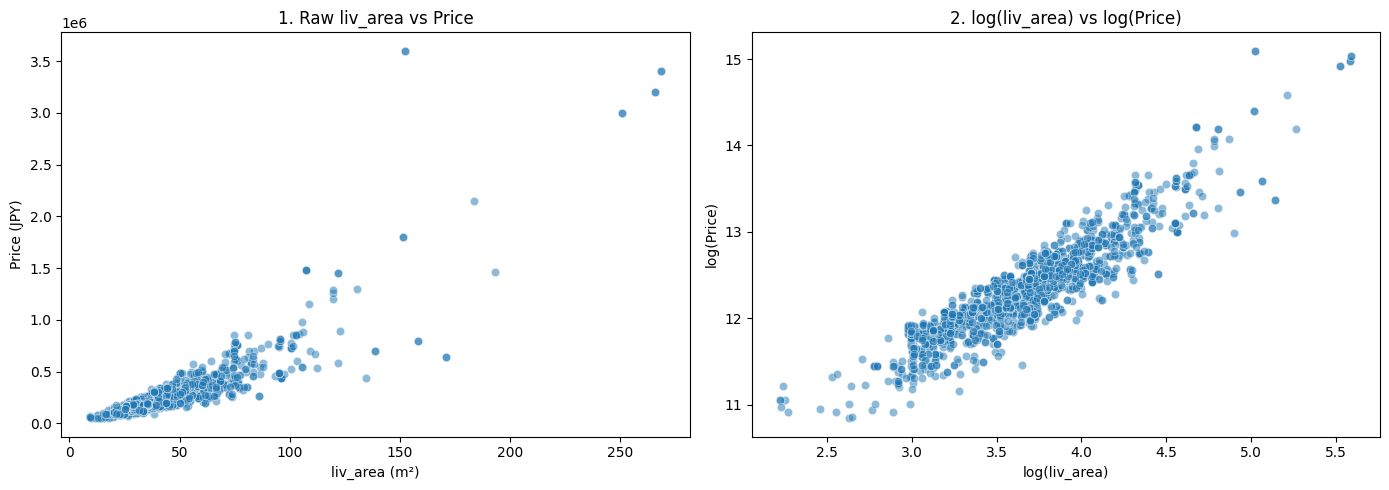

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 専有面積 vs 生の家賃（生データでの限界効用逓減の確認）
sns.scatterplot(data=df, x="liv_area", y="price", ax=axes[0], alpha=0.5)
axes[0].set_title("1. Raw liv_area vs Price")
axes[0].set_xlabel("liv_area (m²)")
axes[0].set_ylabel("Price (JPY)")

# 2. 対数専有面積 vs 対我家賃（Log-Logモデルの線形性確認）
sns.scatterplot(
    x=np.log(df["liv_area"]), y=np.log(df["price"]), ax=axes[1], alpha=0.5
)
axes[1].set_title("2. log(liv_area) vs log(Price)")
axes[1].set_xlabel("log(liv_area)")
axes[1].set_ylabel("log(Price)")

plt.tight_layout()
plt.show()

In [6]:
import statsmodels.formula.api as smf

# v1: liv_area を線形で投入したヘドニックOLS
formula_v1 = (
    "np.log(price) ~ station_distance + floor + liv_area + age + total_floors"
)
model_v1 = smf.ols(formula_v1, data=df).fit()

# サマリーの表示
print("=== Phase 1 v1 Summary ===")
print(model_v1.summary())

=== Phase 1 v1 Summary ===
                            OLS Regression Results                            
Dep. Variable:          np.log(price)   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     1468.
Date:                Tue, 11 Aug 2026   Prob (F-statistic):               0.00
Time:                        05:27:59   Log-Likelihood:                 55.398
No. Observations:                1659   AIC:                            -98.80
Df Residuals:                    1653   BIC:                            -66.31
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept    

In [7]:
# v2: log(liv_area) を投入し、弾力性モデルへ変更
formula_v2 = "np.log(price) ~ station_distance + floor + np.log(liv_area) + age + total_floors"
model_v2 = smf.ols(formula_v2, data=df).fit()

print("=== Phase 1 v2 Summary ===")
print(model_v2.summary())

=== Phase 1 v2 Summary ===
                            OLS Regression Results                            
Dep. Variable:          np.log(price)   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     2272.
Date:                Tue, 11 Aug 2026   Prob (F-statistic):               0.00
Time:                        05:40:56   Log-Likelihood:                 361.81
No. Observations:                1659   AIC:                            -711.6
Df Residuals:                    1653   BIC:                            -679.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept    

In [13]:

formula_v3 = "np.log(price) ~ station_distance + floor + np.log(liv_area) + age + total_floors + C(address)"
model_v3 = smf.ols(formula_v3, data=df).fit()

print("=== Phase 1 v3 Summary ===")
print(model_v3.summary())

=== Phase 1 v3 Summary ===
                            OLS Regression Results                            
Dep. Variable:          np.log(price)   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     308.5
Date:                Tue, 11 Aug 2026   Prob (F-statistic):               0.00
Time:                        08:16:25   Log-Likelihood:                 961.91
No. Observations:                1659   AIC:                            -1766.
Df Residuals:                    1580   BIC:                            -1338.
Df Model:                          78                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

In [14]:
# v3 の主要変数の係数・P値を確認
main_vars = ['station_distance', 'age', 'floor', 'np.log(liv_area)']
print(pd.DataFrame({
    'v3 Coef': model_v3.params[main_vars],
    'v3 p-val': model_v3.pvalues[main_vars].round(4)
}))

                   v3 Coef  v3 p-val
station_distance -0.001005    0.6621
age               0.008189    0.0000
floor             0.010227    0.0000
np.log(liv_area)  1.002079    0.0000


In [26]:
comparison = pd.DataFrame(
    {
        "v1 Coef": model_v1.params.round(4),
        "v1 p-val": model_v1.pvalues.round(4),
        "v2 Coef": model_v2.params.round(4),
        "v2 p-val": model_v2.pvalues.round(4),
    }
)

print("=== Model Comparison (v1 vs v2) ===")
print(comparison)

=== Model Comparison (v1 vs v2) ===
                  v1 Coef  v1 p-val  v2 Coef  v2 p-val
Intercept         -4.7749    0.0000  -5.4655     0.000
age                0.0080    0.0000   0.0067     0.000
floor              0.0110    0.0000   0.0075     0.000
liv_area           0.0197    0.0000      NaN       NaN
np.log(liv_area)      NaN       NaN   1.1131     0.000
station_distance   0.0003    0.8767   0.0045     0.009
total_floors       0.0116    0.0000   0.0083     0.000


In [27]:
# address から「丁目・番地」を除外して「町名レベル」の列を作成（細かくしすぎてサンプル少なかった可能性あったため）
df['area_group'] = df['address'].str.extract(r'(東京都.+?[区市].+?[一-龠]+)')

# area_group を固定効果として投入
formula_v4 = "np.log(price) ~ station_distance + floor + np.log(liv_area) + age + total_floors + C(area_group)"
model_v4 = smf.ols(formula_v4, data=df).fit()

print("=== Phase 1 v4 Summary ===")
print(model_v4.summary())

=== Phase 1 v4 Summary ===
                            OLS Regression Results                            
Dep. Variable:          np.log(price)   R-squared:                       0.923
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                     551.1
Date:                Tue, 11 Aug 2026   Prob (F-statistic):               0.00
Time:                        08:58:23   Log-Likelihood:                 708.17
No. Observations:                1551   AIC:                            -1348.
Df Residuals:                    1517   BIC:                            -1167.
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [31]:
main_vars = ["station_distance", "age", "floor", "np.log(liv_area)"]
print(
    pd.DataFrame(
        {
            "v4 Coef": model_v4.params[main_vars],
            "v4 p-val": model_v4.pvalues[main_vars].round(4),
        }
    )
)

                   v4 Coef  v4 p-val
station_distance -0.001600    0.3509
age               0.008539    0.0000
floor             0.010537    0.0000
np.log(liv_area)  1.038495    0.0000


In [32]:
import numpy as np
import pandas as pd

# 1. v4モデルの入力に必要な変数に欠損がないレコードで評価用データを作成
eval_cols = [
    "price",
    "station_distance",
    "floor",
    "liv_area",
    "age",
    "total_floors",
    "area_group",
]
df_eval = df.dropna(subset=eval_cols).copy()

# 2. 予測値（適正価格）の算出：np.log(price) の予測値を exp で実価格スケール（円）へ変換
df_eval["pred_price_v4"] = np.exp(model_v4.predict(df_eval))

# 3. 乖離率の算出: (実価格 - 適正価格) / 適正価格
df_eval["div_rate_v4"] = (
    df_eval["price"] - df_eval["pred_price_v4"]
) / df_eval["pred_price_v4"]

# 4. 割安・割高件数の集計
total_count = len(df_eval)
undervalued_count = (df_eval["div_rate_v4"] < -0.05).sum()
overvalued_count = (df_eval["div_rate_v4"] > 0.05).sum()

# 5. 最も割安な物件の特定（乖離率が最も小さい/マイナスが大きい物件）
top_undervalued = df_eval.sort_values("div_rate_v4").iloc[0]

# 6. phase1_summary.md 貼り付け用の結果出力
print("=== docs/phase1_summary.md 転記用データ ===")
print(
    f"- 割安（乖離率 < -5%）: {undervalued_count}件 / 割高（> +5%）: {overvalued_count}件（全{total_count}件中）"
)

# 物件名または識別カラムが存在する場合は表示（環境の列名に合わせて確認）
name_col = (
    "title"
    if "title" in top_undervalued
    else ("building_name" if "building_name" in top_undervalued else "room_id")
)
print(
    f"- 最も割安な物件: {top_undervalued[name_col]}（乖離率 {top_undervalued['div_rate_v4'] * 100:.1f}%）"
)
print("\n--- 詳細チェック用 ---")
print(f"  実価格: {int(top_undervalued['price']):,} 円")
print(f"  適正価格（予測）: {int(top_undervalued['pred_price_v4']):,} 円")

=== docs/phase1_summary.md 転記用データ ===
- 割安（乖離率 < -5%）: 571件 / 割高（> +5%）: 513件（全1551件中）
- 最も割安な物件: 587（乖離率 -49.0%）

--- 詳細チェック用 ---
  実価格: 435,000 円
  適正価格（予測）: 853,132 円


## 実データによるモデル検証と定式化の再評価（手動検証ログ）

AIが事前構築した因果推論モデル（DAGおよび建物固定効果）に対し、実際のスクレイピングデータを用いて定式化の妥当性と交絡の挙動を直接検証した。

### 1. 識別された定式化の欠陥と修正（v1 → v2）
- **広さの外挿エラー**: 初期モデルの線形投入（`liv_area`）では、100㎡超の物件で予測価格が900万円を超える外挿崩壊が発生した。
- **解決策**: 両対数モデル（`np.log(liv_area)`）へ改修。広さの弾力性を約1.0〜1.1に収束させ、限界効用逓減を数式に反映することで外挿エラーを解消（$R^2: 0.816 \rightarrow 0.873$）。

### 2. 固定効果の抽象度と多重共線性（v3 → v4）
- **過剰制御（Over-controlling）の発見**: 丁目単位（`C(address)`）で固定効果を入れると、同一丁目内の駅徒歩分数の分散が消失し、`station_distance` の $p$ 値が0.66まで不有意化した（Condition Number: $4.4 \times 10^5$）。
- **粒度調整**: 町名レベル（`C(area_group)`）へ抽象度を落とすことで、エリアブランドを吸い上げつつ駅徒歩の同一グループ内変動を復元させた（$R^2: 0.923$）。

### 3. 因果推論の限界と残存交絡の特定
- **渋谷区特有の未観測交絡**: エリア固定効果を投入しても `age`（築年数）の係数が正（古いほど高い）にとどまる現象を確認。
- **構造的原因**: データ内に「リノベーションの有無」「ヴィンテージマンションの仕様」が含まれていないため、`age` がこれら高級仕様の代理変数として機能していることを実データから特定。

### 4. 結論
線形モデル（OLS）では「非線形な距離減価」や「未観測仕様による多重交絡」を吸収しきれない限界が明確になったため、Phase 2ではここで得た特徴量加工（Log変換・エリアエンコーディング）を保持したまま、非線形・交互作用を柔軟に捉える決定木系モデル（LightGBM）へ移行する。